In [1]:
import numpy as np
import math, warnings
import gymnasium as gym          # 你已经装了 gymnasium 1.3.0，直接用
warnings.filterwarnings('ignore')

env = gym.make('CliffWalking-v1')   # ← 关键改动：gymnasium 1.3.0 用 v1（v0 已弃用）
np.random.seed(1)                   # 设随机种子，便于复现
n_states = env.observation_space.n  # 48
n_actions = env.action_space.n      # 4
print(f"状态数：{n_states}，动作数：{n_actions}")

state, _ = env.reset()              # gymnasium: reset() 返回 (obs, info)
print(f"初始状态：{state}")          # 预期 36（左下角起点）


状态数：48，动作数：4
初始状态：36


In [2]:
class QLearning:
    def __init__(self, n_states, n_actions, cfg):
        self.n_actions = n_actions
        self.lr = cfg['lr']
        self.gamma = cfg['gamma']
        self.epsilon_start = cfg['epsilon_start']
        self.epsilon_end = cfg['epsilon_end']
        self.epsilon_decay = cfg['epsilon_decay']
        self.sample_count = 0
        self.Q_table = np.zeros((n_states, n_actions))   # 48×4 的 Q 表格

    def choose_action(self, state):
        # ε-贪心：ε 随采样次数指数递减（教材 p.67）
        self.sample_count += 1
        self.epsilon = self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
            math.exp(-1. * self.sample_count / self.epsilon_decay)
        if np.random.uniform(0, 1) > self.epsilon:        # 利用
            return np.argmax(self.Q_table[state])
        return np.random.choice(self.n_actions)           # 探索

    def update(self, state, action, reward, next_state, done):
        # 式 (3.33)：Q(S,A) ← Q(S,A) + α[R + γ·max_a Q(S′,a) − Q(S,A)]（教材 p.68）
        Q_predict = self.Q_table[state][action]
        if done:                                          # 终止状态拿不到下一动作
            Q_target = reward
        else:
            Q_target = reward + self.gamma * np.max(self.Q_table[next_state])
        self.Q_table[state][action] += self.lr * (Q_target - Q_predict)


In [3]:
cfg = {'lr': 0.1, 'gamma': 0.9, 'epsilon_start': 0.9, 'epsilon_end': 0.01, 'epsilon_decay': 200}
agent = QLearning(n_states, n_actions, cfg)

train_eps = 500
max_steps = 200        # 防死循环保护：每回合最多走 200 步（教材原代码没有，但若策略没学好可能永远到不了终点）
rewards, ma_rewards = [], []

for i_ep in range(train_eps):
    ep_reward = 0
    state, _ = env.reset()
    for step in range(max_steps):
        action = agent.choose_action(state)                              # ② 选动作
        next_state, reward, terminated, truncated, _ = env.step(action)  # ③ 环境反馈（5元组）
        done = terminated or truncated                                   # CliffWalking 中 truncated 恒 False
        agent.update(state, action, reward, next_state, done)            # ④ 更新策略
        state = next_state
        ep_reward += reward
        if done:                                                         # 到终点(47)才结束回合
            break
    rewards.append(ep_reward)
    # 滑动平均：ma = 0.9×上一个 + 0.1×本回合（教材 p.67）
    ma_rewards.append(ma_rewards[-1] * 0.9 + ep_reward * 0.1 if ma_rewards else ep_reward)

print("训练最后10回合奖励：", rewards[-10:])
print("最优应为 -13（13 步到达终点）")


训练最后10回合奖励： [-15, -13, -13, -15, -13, -13, -13, -13, -13, -13]
最优应为 -13（13 步到达终点）


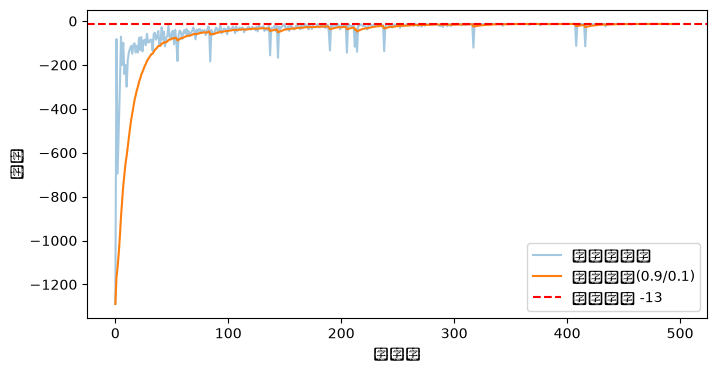

In [6]:
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.plot(rewards, alpha=0.4, label='每回合奖励')
    plt.plot(ma_rewards, label='滑动平均(0.9/0.1)')
    plt.axhline(-13, color='r', linestyle='--', label='理论最优 -13')
    plt.xlabel('回合数'); plt.ylabel('奖励'); plt.legend(); plt.show()
except ImportError:
    print('未安装 matplotlib，跳过画图')


In [7]:
test_eps = 30
test_rewards = []
for _ in range(test_eps):
    ep_reward = 0
    state, _ = env.reset()
    for step in range(max_steps):
        action = np.argmax(agent.Q_table[state])   # 测试时纯利用，不探索
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        ep_reward += reward
        if terminated or truncated:
            break
    test_rewards.append(ep_reward)

print("测试30回合奖励：", test_rewards)
print("测试平均奖励：", round(float(np.mean(test_rewards)), 2), "（理论最优 -13）")
env.close()


测试30回合奖励： [-13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13, -13]
测试平均奖励： -13.0 （理论最优 -13）
